# Libraries

In [ ]:
%load_ext tensorboard

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorboard as tb

from scipy.stats import f_oneway, ttest_ind

import warnings
warnings.filterwarnings("ignore")

# Download from Tensorboard 

In [ ]:
!wget "https://github.com/ibrahimerdem/application_storage/raw/main/last-event-app/tuning_logs.zip"
!unzip "tuning_logs.zip"

In [ ]:
!unzip "results.zip"

Archive:  results.zip
  inflating: logs/tune/events.out.tfevents.1640183620.720ae277f1c3.24.0.v2  
  inflating: logs/tune/model1-0-1/events.out.tfevents.1640183632.720ae277f1c3.24.1.v2  
  inflating: logs/tune/model1-0-2/events.out.tfevents.1640183716.720ae277f1c3.24.2.v2  
  inflating: logs/tune/model1-1-1/events.out.tfevents.1640183790.720ae277f1c3.24.3.v2  
  inflating: logs/tune/model1-1-2/events.out.tfevents.1640183934.720ae277f1c3.24.4.v2  


In [ ]:
%tensorboard --logdir=logs

# Auxilary Functions

In [ ]:
def grouper(df):
    return df.groupby(
    ["model_num", "emb_units", "rnn_units", "drop_rate", "l_rate"],
     as_index=False).agg(
        {"accuracy":["mean", "std"]})
tune_df = pd.DataFrame(index=["model_num", "emb_units",	"rnn_units",
                              "drop_rate", "l_rate", "acc_mean", "acc_std"])

# Tuning Results

In [ ]:
r = pd.read_csv("tuning_results.csv")

r = r.sort_values(["model_num", "emb_units", "rnn_units",
                   "drop_rate", "l_rate", "replication"], ignore_index=True)

In [ ]:
r

## Top5

In [ ]:
t5 = grouper(r)

In [ ]:
for i in range(1, 9):
    t = t5[t5["model_num"]==i]
    display(t.sort_values(("accuracy", "mean"),
                          ascending=False,
                          ignore_index=True).head(5))

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       1.0      96.0     100.0       0.8  0.001  0.319180  0.000554
1       1.0     128.0     200.0       0.8  0.001  0.318700  0.002956
2       1.0     128.0     300.0       0.8  0.001  0.316915  0.000308
3       1.0      96.0     300.0       0.8  0.001  0.315652  0.000985
4       1.0      96.0     200.0       0.8  0.001  0.314999  0.006713

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       2.0      64.0     100.0       0.6  0.001  0.335119  0.004989
1       2.0     128.0     200.0       0.8  0.001  0.333551  0.006960
2       2.0     128.0     100.0       0.8  0.001  0.332811  0.004804
3       2.0     128.0     100.0       0.6  0.001  0.330851  0.000924
4       2.0      96.0     300.0       0.8  0.001  0.330851  0.006467

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       3.0     128.0     200.0       0.8  0.001  0.338603  0.003634
1       3.0      64.0     200.0       0.8  0.001  0.335946  0.003079
2       3.0      96.0     300.0       0.8  0.001  0.333072  0.006898
3       3.0     128.0     300.0       0.8  0.001  0.332375  0.004188
4       3.0      96.0     200.0       0.8  0.001  0.331591  0.009977

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       4.0      96.0     200.0       0.8  0.001  0.334074  0.002895
1       4.0      64.0     200.0       0.8  0.001  0.328107  0.007514
2       4.0     128.0     100.0       0.6  0.001  0.327672  0.006282
3       4.0     128.0     300.0       0.8  0.001  0.326975  0.003449
4       4.0      32.0     100.0       0.6  0.001  0.325320  0.006775

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       5.0      64.0     200.0       0.8  0.001  0.332462  0.001109
1       5.0      96.0     300.0       0.8  0.001  0.330590  0.003880
2       5.0     128.0     200.0       0.8  0.001  0.330590  0.003757
3       5.0      96.0     100.0       0.8  0.001  0.329370  0.006713
4       5.0      96.0     200.0       0.8  0.001  0.328412  0.012256

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       6.0     128.0     200.0       0.8  0.001  0.331417  0.001478
1       6.0      64.0     200.0       0.8  0.001  0.331112  0.005851
2       6.0      64.0     300.0       0.8  0.001  0.329936  0.002710
3       6.0      96.0     300.0       0.8  0.001  0.329153  0.000370
4       6.0      32.0     200.0       0.8  0.001  0.328107  0.002710

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       7.0     128.0     200.0       0.8  0.001  0.339474  0.007329
1       7.0      96.0     100.0       0.6  0.001  0.334988  0.007391
2       7.0      96.0     200.0       0.8  0.001  0.334596  0.003634
3       7.0      64.0     300.0       0.8  0.001  0.334117  0.001109
4       7.0      64.0     500.0       0.8  0.001  0.331504  0.002587

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       8.0      64.0     200.0       0.8  0.001  0.337384  0.001417
1       8.0     128.0     300.0       0.8  0.001  0.336817  0.000985
2       8.0     128.0     200.0       0.8  0.001  0.335729  0.004496
3       8.0      64.0     300.0       0.8  0.001  0.333595  0.003942
4       8.0      64.0     100.0       0.8  0.001  0.332593  0.001909

## Best Results

In [ ]:
b = grouper(r)
for i in range(1, 9):
    best = b[b["model_num"]==i]
    best_row = best.sort_values(("accuracy", "mean"),
                                ascending=False,
                                ignore_index=True).head(1)
    display(best_row)
    tune_df[i] = best_row.values.reshape(-1)

model_num emb_units rnn_units drop_rate l_rate accuracy          
                                                     mean       std
0       1.0      96.0     100.0       0.8  0.001  0.31918  0.000554

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       2.0      64.0     100.0       0.6  0.001  0.335119  0.004989

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       3.0     128.0     200.0       0.8  0.001  0.338603  0.003634

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       4.0      96.0     200.0       0.8  0.001  0.334074  0.002895

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       5.0      64.0     200.0       0.8  0.001  0.332462  0.001109

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       6.0     128.0     200.0       0.8  0.001  0.331417  0.001478

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       7.0     128.0     200.0       0.8  0.001  0.339474  0.007329

model_num emb_units rnn_units drop_rate l_rate  accuracy          
                                                      mean       std
0       8.0      64.0     200.0       0.8  0.001  0.337384  0.001417

In [ ]:
tune_df.T

,model_num,emb_units,rnn_units,drop_rate,l_rate,acc_mean,acc_std
1,1.0,96.0,100.0,0.8,0.001,0.319180,0.000554
2,2.0,64.0,100.0,0.6,0.001,0.335119,0.004989
3,3.0,128.0,200.0,0.8,0.001,0.338603,0.003634
4,4.0,96.0,200.0,0.8,0.001,0.334074,0.002895
5,5.0,64.0,200.0,0.8,0.001,0.332462,0.001109
6,6.0,128.0,200.0,0.8,0.001,0.331417,0.001478
7,7.0,128.0,200.0,0.8,0.001,0.339474,0.007329
8,8.0,64.0,200.0,0.8,0.001,0.337384,0.001417


# Experiment Results

In [ ]:
exp = pd.read_csv(
    "app_experiments.csv",
    sep=";")

In [ ]:
eval = exp.groupby(["model", "n_padded"]).mean().drop(columns=["k", "replication"])
eval

,,precision,recall,mrr,hit,coverage
model,n_padded,,,,,
1,32,0.017589,0.048423,0.043661,0.078125,0.061578
2,32,0.016786,0.048814,0.042448,0.075893,0.069445
3,32,0.018571,0.053502,0.045298,0.083482,0.058758
4,32,0.017411,0.051879,0.043088,0.078571,0.057637
5,32,0.019286,0.054644,0.048214,0.087500,0.058213
6,32,0.018125,0.052136,0.043504,0.081250,0.053976
7,32,0.022321,0.062175,0.052991,0.097768,0.059241
8,32,0.020893,0.057835,0.050186,0.091071,0.061858


## Last-Event

### n_padded = 24 (hit)

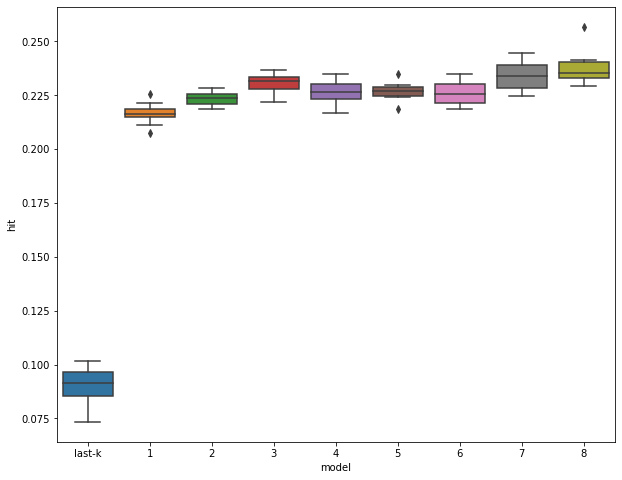

In [ ]:
fig = plt.figure(1, [10, 8])
ax = sns.boxplot(x="model", y="hit",
                 data=exp[(exp["k"]==5) & (exp["n_padded"]==24)])
plt.show()

In [ ]:
pvt24 = pd.pivot_table(exp[(exp["k"]==5)&(exp["n_padded"]==24)],
                     values=["coverage"],
                     columns=["replication"],
                     index=["model"])
pvt24["mean"] = pvt24["coverage"].mean(axis=1)
pvt24["std"] = pvt24["coverage"].std(axis=1)
pvt24

coverage                      ...                mean       std
replication         1         2         3  ...        10                    
model                                      ...                              
1            0.220552  0.206748  0.208819  ...  0.215567  0.210123  0.009027
2            0.270859  0.267868  0.270629  ...  0.268098  0.272209  0.003065
3            0.240261  0.240874  0.234816  ...  0.226304  0.231733  0.007856
4            0.220552  0.224080  0.227607  ...  0.226534  0.216933  0.009290
5            0.215644  0.225997  0.218021  ...  0.216564  0.219601  0.006794
6            0.181058  0.208742  0.189647  ...  0.191564  0.197025  0.008321
7            0.205752  0.213344  0.214187  ...  0.219632  0.213390  0.004880
8            0.214340  0.214801  0.217178  ...  0.223466  0.223520  0.009678
last-k       0.218098  0.211810  0.210276  ...  0.221702  0.218934  0.004875

[9 rows x 12 columns]

In [ ]:
f_oneway(pvt24.values[0][:-2],
         pvt24.values[1][:-2],
         pvt24.values[2][:-2],
         pvt24.values[3][:-2],
         pvt24.values[4][:-2],
         pvt24.values[5][:-2],
         pvt24.values[6][:-2],
         pvt24.values[7][:-2])

F_onewayResult(statistic=13.113610141925788, pvalue=9.20614591547116e-11)

In [ ]:
ttest_ind(pvt24.values[7][:-2], pvt24.values[5][:-2])

Ttest_indResult(statistic=4.122899131582774, pvalue=0.0006388361978589487)

### n_padded = 32 (hit)

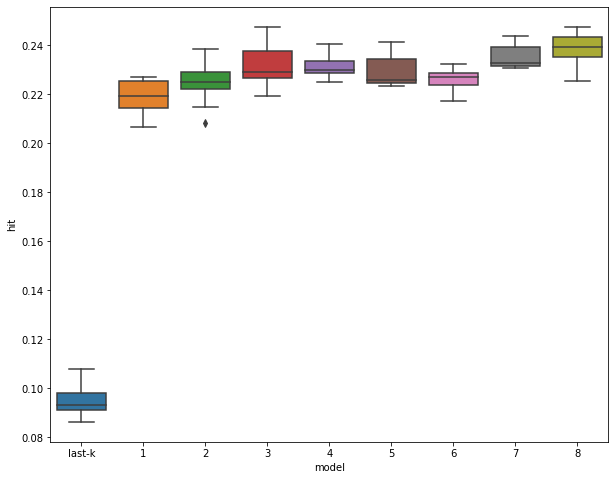

In [ ]:
fig = plt.figure(1, [10, 8])
ax = sns.boxplot(x="model", y="hit",
                 data=exp[(exp["k"]==5) & (exp["n_padded"]==32)])
plt.show()

In [ ]:
pvt32 = pd.pivot_table(exp[(exp["k"]==5)&(exp["n_padded"]==32)],
                     values=["coverage"],
                     columns=["replication"],
                     index=["model"])
pvt32["mean"] = pvt32["coverage"].mean(axis=1)
pvt32["std"] = pvt32["coverage"].std(axis=1)
pvt32

coverage                      ...                mean       std
replication         1         2         3  ...        10                    
model                                      ...                              
1            0.214877  0.198006  0.195629  ...  0.198696  0.202477  0.007912
2            0.280291  0.278298  0.278604  ...  0.278911  0.280330  0.005106
3            0.229985  0.223773  0.218942  ...  0.217868  0.221296  0.006350
4            0.206288  0.229601  0.200997  ...  0.227147  0.212025  0.012128
5            0.221626  0.199003  0.215644  ...  0.203911  0.213152  0.009205
6            0.198390  0.190798  0.201534  ...  0.184202  0.194486  0.010001
7            0.210429  0.206135  0.206748  ...  0.199693  0.206549  0.004144
8            0.222469  0.206748  0.208589  ...  0.220859  0.217952  0.007028
last-k       0.228374  0.218558  0.205061  ...  0.225690  0.217393  0.008192

[9 rows x 12 columns]

In [ ]:
f_oneway(pvt32.values[0][:-2],
         pvt32.values[1][:-2],
         pvt32.values[2][:-2],
         pvt32.values[3][:-2],
         pvt32.values[4][:-2],
         pvt32.values[5][:-2],
         pvt32.values[6][:-2],
         pvt32.values[7][:-2])

F_onewayResult(statistic=11.518524078454929, pvalue=1.0162020622835757e-09)

In [ ]:
ttest_ind(pvt32.values[7][:-2], pvt32.values[5][:-2])

Ttest_indResult(statistic=4.46814963272757, pvalue=0.00029716770206900204)

## Time-Basis

### n_padded = 32 (recall)

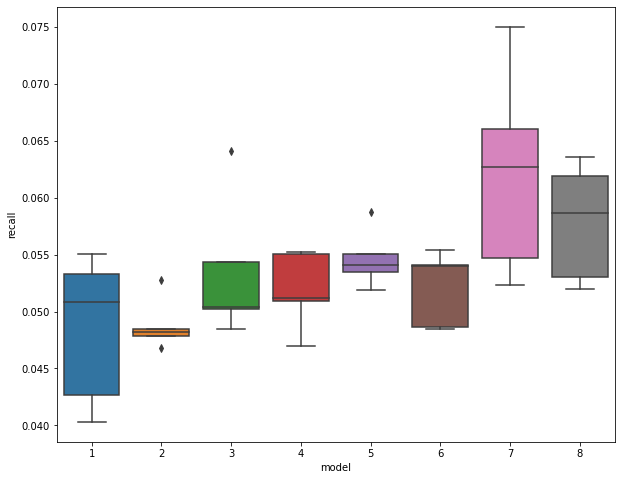

In [ ]:
fig = plt.figure(1, [10, 8])
ax = sns.boxplot(x="model", y="recall",
                 data=exp[(exp["k"]==5) & (exp["n_padded"]==32)])
plt.show()

In [ ]:
pvt10 = pd.pivot_table(exp[(exp["k"]==5)&(exp["n_padded"]==32)],
                     values=["coverage"],
                     columns=["replication"],
                     index=["model"])
pvt10["mean"] = pvt10["coverage"].mean(axis=1)
pvt10["std"] = pvt10["coverage"].std(axis=1)
pvt10

coverage                      ...                mean       std
replication         1         2         3  ...         5                    
model                                      ...                              
1            0.063167  0.059974  0.057948  ...  0.064102  0.061578  0.002545
2            0.070099  0.067295  0.068152  ...  0.071345  0.069445  0.001667
3            0.056624  0.056780  0.061531  ...  0.059662  0.058758  0.002071
4            0.056235  0.057247  0.057793  ...  0.058026  0.057637  0.000981
5            0.057403  0.058649  0.060597  ...  0.057014  0.058213  0.001468
6            0.050939  0.055612  0.052418  ...  0.054911  0.053976  0.002197
7            0.060597  0.058961  0.057948  ...  0.056780  0.059241  0.002051
8            0.063401  0.062622  0.058727  ...  0.063478  0.061858  0.002001

[8 rows x 7 columns]

In [ ]:
f_oneway(pvt10.values[0][:-2],
         pvt10.values[1][:-2],
         pvt10.values[2][:-2],
         pvt10.values[3][:-2],
         pvt10.values[4][:-2],
         pvt10.values[5][:-2],
         pvt10.values[6][:-2],
         pvt10.values[7][:-2])

F_onewayResult(statistic=7.5178008111761905, pvalue=2.3247517914853605e-05)

In [ ]:
ttest_ind(pvt10.values[6][:-2], pvt10.values[0][:-2])

Ttest_indResult(statistic=3.0973151269850834, pvalue=0.014725500988358222)